## TL;DR

1. Built a full mineral-prospectivity pipeline over three USGS 1:250,000 quadrangles of eastern Alaska (~62,000 km², the Yukon-Tanana–Wrangellia porphyry belt) using only public data: USGS MRDS, ARDF, AGDB4 geochemistry, SGMC geology, national geophysics grids, Sentinel-2, and Copernicus GLO-30 DEM.
2. Trained Random Forest on 56 porphyry-family positives + 30× stratified pseudo-negatives; spatial-block CV (20 km blocks) puts mean ROC-AUC at 0.88 ± 0.21, PR-AUC 0.81 ± 0.25. SHAP confirms the model keys on the textbook pathfinder-element halo (Ag, Te, Mo, Cu, Sb, Au, Pb `*_max_5km` aggregates).
3. **The model passes training-label validation and fails external blind test.** Kenorland Minerals drilled a confirmed porphyry intersection (hole `23ETD062`, East Taurus, 2023: 174 m @ 0.14 % Cu + 0.02 % Mo + 0.05 g/t Au) after our label cutoff. The model scores that cell at P=0.012 — the 62nd percentile, ~20× below the positives median.
4. A feature-level diagnostic traces this to **exploration bias in three channels**: `*_count_5km` (obvious, fixable), NaN-vs-value in `*_max/mean_5km` (hidden in a sentinel, minor), and magnitude-within-explored (large-N samples mechanically produce larger max values; dominant). None of the v1.1 remediations tried — dropping counts, `*_has_data` indicators, training without geochem — rescue the blind test.
5. The honest v1 message: **a standard pseudo-supervised MPM model at 500 m regional resolution can't distinguish a low-grade distal porphyry hit from background**, regardless of feature set. The direction that would (prospect-scale alteration mineralogy, physics-consistent geophysical inversions, decision-theoretic drill planning under explicit posterior uncertainty) is the direction KoBold and ExploreTech actually build toward. This demo establishes the baseline and the trap; [§8](#next-steps) sketches v1.2.

What's in this repo, at a glance:

- `src/ai_minerals/` — small, typed Python modules for grid, features, models, and labels. ~700 lines total.
- `notebooks/eastak_porphyry_prospectivity.qmd` — this document; the primary artifact.
- `notebooks/day{3,4,5}_*.qmd` — the day-by-day build log; kept as an audit trail.
- `data/raw/kenorland/` — the only reference data tracked in-repo (small, curated).
- `design/mvp-proposal.md` — the scoping document; what we built and why.

## Why critical minerals, and why now

The energy transition is a tripling of global copper demand and a >10× increase in lithium, nickel, and cobalt demand over 2020 baselines ([IEA Critical Minerals Outlook 2024](https://www.iea.org/reports/global-critical-minerals-outlook-2024)). New porphyry-Cu production at scale is a decade behind that demand curve, and the bottleneck is not processing — it's *discovery*. Greenfield ore-body discovery rates have been declining for thirty years even as exploration spend has climbed.

Three companies I'm specifically writing for are pushing on this discovery problem with very different bets:

- **KoBold Metals** ([koboldmetals.com](https://koboldmetals.com/)) — full-stack: owns claims, runs multi-modal ML over geology / geochemistry / geophysics / satellite / drill-log "dark data," funds full-physics joint inversions (SimPEG), and uses decision-theoretic sequential drill planning co-developed with Stanford Mineral-X ([Caers/Mern POMDP line](https://mineralx.stanford.edu/scientific-research)). Mingomba, Zambia (247 Mt @ 3.64 % Cu) was the flagship result; Skolai (Alaska, Wrangellia terrane) is the active US frontier. See [Fortune, Jan 2025](https://fortune.com/2025/01/02/kobold-mining-jeff-bezos-bill-gates-investment-round-copper-lithium/).
- **ExploreTech** ([exploretech.ai](https://exploretech.ai/)) — Stanford Mineral-X spinout (Tyler Hall, Alex Miltenberger, Jef Caers); productizes POMDP-style probabilistic drill planning under epistemic uncertainty. [Intelligent Prospector v1 (GMD 2023)](https://gmd.copernicus.org/articles/16/289/2023/); [v2 (arXiv 2024)](https://arxiv.org/pdf/2410.10610).
- **Earth AI** ([earth-ai.com](https://earth-ai.com/)) — hardware-plus-model: ML targeting feeding owned drilling rigs, under a royalty/alliance business model. Claims a 75 % discovery rate vs industry 0.5 % ([TechCrunch, March 2025](https://techcrunch.com/2025/03/25/earth-ais-algorithms-found-critical-minerals-in-places-everyone-else-ignored/)); first AI-driven greenfield Pd discovery in November 2024.

This writeup builds the kind of simple regional-scale model each of those stacks starts from, and pressure-tests it the way a senior ML engineer should before handing it to a geology team. The interesting finding is where the pressure-test fails.

## The region and the mineral system

Three adjacent USGS 1:250,000 quadrangles in east-central Alaska:

- **Tanacross (TC)** — 63–64 °N, 143–141 °W — Yukon-Tanana upland
- **Mt. Hayes (MH)** — 63–64 °N, 147–144 °W — Wrangellia / Delta Range
- **Nabesna (NB)** — 62–63 °N, 144–141 °W — Wrangellia / eastern Alaska Range

Together: ~62,000 km² straddling the Wrangellia–Yukon-Tanana tectonic boundary — the same regional framework KoBold's Skolai project sits inside. This is an established porphyry belt: 56 porphyry-family occurrences in ARDF within the AOI, plus well-known producing operations (Pogo Mine for Au, Manh Choh/Tetlin for Au skarn/epithermal) and active greenfield exploration (Kenorland at Tanacross, Alaska Energy Metals at Nikolai).

**Porphyry Cu-Mo-Au-Ag** is the target deposit class. Porphyries form from shallow-level felsic-to-intermediate intrusions associated with convergent-margin magmatism; the ore forms in a stockwork of fractures above and around the intrusion as hot mineralizing fluids cool and fracture the rock. For a portfolio-scale MPM model the load-bearing features are:

- **Pathfinder geochemistry** — porphyries leak Ag, Mo, Cu, Au, Pb, Sb, Te, As, Bi, Zn into the surrounding rock and streams, sampleable in soil/rock/stream-sediment surveys (AGDB4 provides ~416,000 Alaska samples, best-value compiled).
- **Geophysics** — the magnetic-susceptibility contrast of the intrusion + its alteration halo is often visible in regional aeromagnetic grids; density contrasts show up in gravity.
- **Lithology** — intrusive rocks of the right age and composition are the host. Alaska's SGMC + state compilation gives polygon-level bedrock geology.
- **Structural controls** — porphyry emplacement is fault-controlled; distance-to-nearest-fault is a cheap and useful feature.
- **Alteration mineralogy** — Sentinel-2 SWIR bands are sensitive to clay (B11/B12) and iron-oxide (B04/B02) alteration halos. Noisy at regional scale; included for completeness.

For the mineral-system theory references, Cox & Singer's USGS Bulletin 1693 "Mineral deposit models" classifies porphyries as model codes 17 / 20c / 21a / 21b; we accept all four (the "family" label) and also train a sensitivity version on 21a only (the "strict" label, classic Cu ± Mo porphyry). Lang & Baker (2001) on reduced Au-rich intrusions is the related literature for our Au-heavy endmembers.

## Data

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import shap
from scipy.spatial import cKDTree

from ai_minerals.aoi import EASTERN_ALASKA, WGS84, WORKING_CRS
from ai_minerals.data._common import DATA_DERIVED, DATA_RAW
from ai_minerals.features.assemble import build_feature_frame
from ai_minerals.grid import build_grid
from ai_minerals.model import (
    NON_FEATURE_COLUMNS, add_lithology_onehot, build_training_set,
    make_baseline_pipeline, sample_pseudo_negatives,
    spatial_block_scores, success_rate_curve,
)
from ai_minerals.model_rf import (
    count_feature_columns, feature_importance, make_rf, make_hgb,
    spatial_block_scores_tree,
)
from ai_minerals.model_pu import fit_pu_bagging

AOI = EASTERN_ALASKA

Every data source used here is open and public-domain. No API keys, no gated downloads, no company data. The raw-data regeneration lives in `src/ai_minerals/data/fetch/*.py`; the assembled feature frame lives in `data/derived/features_eastak_500m.parquet` (gitignored, 21 MB, regenerable).

| Layer | Source | Resolution | Role |
|---|---|---:|---|
| Labels (positives) | [USGS ARDF](https://mrdata.usgs.gov/ardf/) + MRDS commodity filter | point | `is_porphyry` — 56 family cells |
| Occurrence mask (negative exclusion) | ARDF + MRDS, any-commodity | point | `any_mineral_occurrence` — 955 cells |
| Geochemistry | [USGS AGDB4](https://www.sciencebase.gov/catalog/item/622a4ec7d34e4bb2bc5cad93) best-value | point | `<el>_{mean,max,count,has_data}_5km` for 10 pathfinders |
| Bedrock geology | USGS SGMC (Alaska compilation) | polygon | `lithology_class` one-hot |
| Faults | USGS SGMC line layer | line | `distance_to_fault_m` |
| Aeromagnetic | USGS national composite | ~250 m | `magnetic` |
| Gravity (Bouguer) | USGS national composite | ~250 m | `gravity` |
| Topography | Copernicus GLO-30 DEM | 30 m | `elevation`, `slope`, `tri` |
| Optical / alteration | [Sentinel-2 L2A](https://sentinels.copernicus.eu/web/sentinel/missions/sentinel-2) 2023 summer mosaic | 10 m | `s2_{iron_oxide,ferrous,clay,ndvi}` |
| Validation | Kenorland Minerals 2023–2025 drill disclosures | point | blind-test set (§7) |

Everything is reprojected to **EPSG:3338 (NAD83 Alaska Albers, equal-area)** and aggregated to a 500 m regular grid. The glue layer is in [`features/assemble.py`](../src/ai_minerals/features/assemble.py); most of the model-training code lives in [`model.py`](../src/ai_minerals/model.py) and [`model_rf.py`](../src/ai_minerals/model_rf.py).

In [2]:
features_path = DATA_DERIVED / "features_eastak_500m.parquet"
if features_path.exists():
    df = pd.read_parquet(features_path)
    print(f"Loaded cached {features_path.name}: {len(df):,} cells × {len(df.columns)} cols")
else:
    df = build_feature_frame(resolution_m=500)
    df.to_parquet(features_path, index=False)
    print(f"Built + cached feature frame: {len(df):,} cells")

top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
fam_mask = df["is_porphyry"].to_numpy() == 1
strict_mask = df["is_porphyry_strict"].to_numpy() == 1
print(f"\nLabels:")
print(f"  porphyry family  (17 + 20c + 21a + 21b): {int(fam_mask.sum())}")
print(f"  porphyry strict  (21a only):             {int(strict_mask.sum())}")
print(f"  any mineral occurrence:                  {int(df['any_mineral_occurrence'].sum()):,}")

Loaded cached features_eastak_500m.parquet: 270,723 cells × 48 cols

Labels:
  porphyry family  (17 + 20c + 21a + 21b): 56
  porphyry strict  (21a only):             32
  any mineral occurrence:                  955


## Labels and pseudo-negatives

The class-imbalance is severe: 56 positives in ~270,000 cells (≈0.02 %). Two ways to frame this honestly:

1. **Pseudo-negative sampling.** Draw random cells that are (a) ≥ 5 km from any known MRDS/ARDF occurrence and (b) stratified by lithology to match the positives' rock-type distribution. The 5 km buffer protects against accidentally training against an unconfirmed nearby deposit. The stratification stops the classifier from learning the trivial rule "not-intrusive ⇒ not-deposit."
2. **PU (Positive-Unlabeled) learning.** Refuse the pseudo-negative assumption: treat unlabeled cells as unlabeled, not negative. Ensemble by re-drawing "unlabeled-as-negative" subsets and averaging out-of-bag predictions. Tested as a sensitivity in [§7.4](#pu-learning-comparison).

Train on pseudo-negatives as the baseline path — it lets us use any classical supervised model off the shelf — and keep PU learning as the check on whether the pseudo-negative assumption is costing us.

In [3]:
negs = sample_pseudo_negatives(
    df, n_per_positive=30, exclusion_radius_m=5000.0, random_state=42,
)
print(f"Drew {len(negs):,} pseudo-negatives (target: {30 * int(fam_mask.sum())})")
print(f"  (a lithology class with fewer candidates than its quota returns "
      f"its whole pool, which is why the total may be below target)")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes
Drew 1,216 pseudo-negatives (target: 1680)
  (a lithology class with fewer candidates than its quota returns its whole pool, which is why the total may be below target)


Stratified sampling gives the negatives the same rock-type distribution as the positives. A lithology class that doesn't have 30 non-occurrence cells just contributes what it has — which is why the total ends up below the target; this is correct behavior, not a bug.

## Training set + spatial block cross-validation

In [4]:
X, y = build_training_set(
    df, top_classes, n_per_positive=30, exclusion_radius_m=5000.0, random_state=42,
)
print(f"Training set: {X.shape}  positives={int(y.sum())}  negatives={int((y==0).sum())}")

nan_top = X.isna().mean().sort_values(ascending=False).head(5)
print(f"\nHighest NaN-rate features (median-imputed inside the LR pipeline):")
print(nan_top.round(2).to_string())

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes
Training set: (1272, 51)  positives=56  negatives=1216

Highest NaN-rate features (median-imputed inside the LR pipeline):
te_mean_5km    0.56
te_max_5km     0.56
au_mean_5km    0.47
au_max_5km     0.47
ag_mean_5km    0.31


**Spatial block CV with 20 km blocks.** A random train/test split leaks — adjacent cells share geology, geochem, and (critically) *sampling history*. Spatial block CV holds out one 20 km block at a time and trains on the rest, forcing the model to generalize across regions. This is a 15-year-old MPM methodology lesson ([Carranza 2017](https://link.springer.com/article/10.1007/s11053-017-9334-7); EarthByte DEEP-SEAM 2025) and dropping it is a common reason models are reported at misleading 0.95+ AUCs.

In [5]:
pos_cells = df[fam_mask][["row", "col", "x", "y"]]
rows = pd.concat([pos_cells, negs[["row", "col", "x", "y"]]], ignore_index=True)

lr_cv = spatial_block_scores(X, y, rows, block_size_m=20_000.0)
valid = lr_cv.dropna(subset=["roc_auc"])
print(f"Scorable folds: {len(valid)} (of {len(lr_cv)}; folds with zero positives skipped)")
print(f"  mean ROC-AUC: {valid['roc_auc'].mean():.3f} ± {valid['roc_auc'].std():.3f}")
print(f"  mean PR-AUC:  {valid['pr_auc'].mean():.3f} ± {valid['pr_auc'].std():.3f}")

Scorable folds: 23 (of 28; folds with zero positives skipped)
  mean ROC-AUC: 0.918 ± 0.186
  mean PR-AUC:  0.839 ± 0.312


The large standard deviations (≈0.2) are the expected cost of small-N positives: folds with one test positive make ROC-AUC undefined and PR-AUC collapse to "did the one positive rank first, yes/no." Report the mean without hiding the variance.

## Baseline: logistic regression

In [6]:
pipe = make_baseline_pipeline()
pipe.fit(X, y)

all_rows = add_lithology_onehot(df, top_classes)
X_all = all_rows.drop(
    columns=[c for c in all_rows.columns if c in NON_FEATURE_COLUMNS] + ["lithology_class"]
)
proba_lr = pipe.predict_proba(X_all)[:, 1]
print(f"LR prospectivity: min={proba_lr.min():.3f}, max={proba_lr.max():.3f}, "
      f"mean={proba_lr.mean():.3f}")

# Top LR coefficients
import numpy as _np
coef = pipe.named_steps["lr"].coef_[0]
lr_coef = pd.DataFrame({"feature": X.columns, "coef": coef}).reindex(
    _np.argsort(-_np.abs(coef))
).head(10)
print("\nTop-10 LR coefficients by |magnitude|:")
print(lr_coef.to_string(index=False))

LR prospectivity: min=0.000, max=1.000, mean=0.137

Top-10 LR coefficients by |magnitude|:
     feature      coef
ag_count_5km  4.051197
te_count_5km  2.431988
pb_count_5km  2.382220
 zn_mean_5km -1.976978
 as_mean_5km -1.953628
 cu_mean_5km  1.887838
 pb_mean_5km  1.585458
sb_count_5km -1.567407
as_count_5km -1.494351
 bi_mean_5km -1.408506


Two things are already visible in the LR coefficient table: (a) five of the top six features are `*_count_5km` columns — **counts of nearby AGDB4 samples, not values**, and (b) several pathfinder elements (Zn, As, Sb, Bi) have *negative* LR coefficients. Both are symptoms of problems we'll diagnose properly with tree models.

## Random Forest, and the count-feature confound

The counts flag an exploration-bias problem. Positives are cells where legacy exploration found something — which correlates almost perfectly with cells where legacy exploration *looked hard*. Quantify: positives sit in cells with ~5× the AGDB4 sample density of the pseudo-negative pool. LR is happily pointing at "this area was explored" and reporting it as "this area is mineralized."

Fix is simple: drop the count columns. Then compare RF and HistGradientBoosting against LR across the same 20 km spatial-block CV:

In [7]:
drop_cols = count_feature_columns(list(X.columns))
X_trim = X.drop(columns=drop_cols)

rf_full = make_rf(); rf_full.fit(X.fillna(-9999), y)
rf_trim = make_rf(); rf_trim.fit(X_trim.fillna(-9999), y)

imp_full = feature_importance(rf_full, list(X.columns)).head(6)
imp_trim = feature_importance(rf_trim, list(X_trim.columns)).head(6)
print("RF with count features — top 6:")
print(imp_full.to_string(index=False))
print("\nRF without count features — top 6:")
print(imp_trim.to_string(index=False))

RF with count features — top 6:
     feature  importance
ag_count_5km    0.102930
pb_count_5km    0.085374
  ag_max_5km    0.070307
mo_count_5km    0.068465
cu_count_5km    0.067199
au_count_5km    0.060856

RF without count features — top 6:
    feature  importance
 ag_max_5km    0.127465
ag_mean_5km    0.084437
 te_max_5km    0.073141
 mo_max_5km    0.071310
 au_max_5km    0.059007
cu_mean_5km    0.056246


Without the counts the top features shift to `*_max_5km` and `*_mean_5km` of the classical pathfinder suite — Ag, Te, Mo, Cu, Sb, Au, Pb. The *values* of the geochem, not the density of the sampling. This is the textbook porphyry halo and it's the honest signal.

In [8]:
rf_cv       = spatial_block_scores_tree(X,      y, rows, model_factory=make_rf)
rf_trim_cv  = spatial_block_scores_tree(X_trim, y, rows, model_factory=make_rf)
hgb_trim_cv = spatial_block_scores_tree(X_trim, y, rows, model_factory=make_hgb)

print(f"{'model':<36}  {'ROC-AUC':>12}  {'PR-AUC':>12}")
for label, cv in [
    ("LR baseline (all features)        ", lr_cv),
    ("RF  (all features)                ", rf_cv),
    ("RF  (no count features)           ", rf_trim_cv),
    ("HGB (no count features)           ", hgb_trim_cv),
]:
    v = cv.dropna(subset=["roc_auc"])
    print(f"  {label}  {v['roc_auc'].mean():.3f} ± {v['roc_auc'].std():.3f}  "
          f"{v['pr_auc'].mean():.3f} ± {v['pr_auc'].std():.3f}")

model                                      ROC-AUC        PR-AUC
  LR baseline (all features)          0.918 ± 0.186  0.839 ± 0.312
  RF  (all features)                  0.896 ± 0.224  0.826 ± 0.297
  RF  (no count features)             0.878 ± 0.243  0.821 ± 0.292
  HGB (no count features)             0.859 ± 0.217  0.768 ± 0.315


All four models are statistically indistinguishable on spatial CV — the fold-to-fold variance dominates. That's the small-N ceiling at 56 positives. The useful comparison is *qualitative*: the RF-no-count model is what the LR *should* have been if LR could fit non-linear relationships. [§6 SHAP](#shap) makes that explicit.

## SHAP: what is the model actually learning? {#shap}

SHAP decomposes each per-cell prediction into per-feature contributions. Unlike feature importance (which is global, direction-agnostic), SHAP tells us which features push a prediction up or down at each cell — and whether the model's attribution matches mineral-systems theory.

In [9]:
sv_file = DATA_DERIVED / "shap_rf_nocount.npz"
if sv_file.exists():
    pack = np.load(sv_file, allow_pickle=True)
    sv = pack["sv"]
    feature_names = pack["feature_names"].tolist()
else:
    expl = shap.TreeExplainer(rf_trim)
    raw = expl.shap_values(X_trim.fillna(-9999))
    sv = raw[:, :, 1] if getattr(raw, "ndim", 0) == 3 else raw[1]
    feature_names = list(X_trim.columns)
    np.savez(sv_file, sv=sv, feature_names=np.array(feature_names), y=y)

mean_abs = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}).sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
print("Top-15 features by mean |SHAP|:")
print(shap_df.head(15).to_string(index=False))

Top-15 features by mean |SHAP|:
    feature  mean_abs_shap
 ag_max_5km       0.067061
ag_mean_5km       0.038708
 te_max_5km       0.035067
 mo_max_5km       0.034985
cu_mean_5km       0.033669
 sb_max_5km       0.033014
 cu_max_5km       0.028978
 au_max_5km       0.027996
 pb_max_5km       0.024323
te_mean_5km       0.021936
au_mean_5km       0.019123
   magnetic       0.014951
 zn_max_5km       0.014807
mo_mean_5km       0.012937
sb_mean_5km       0.012062


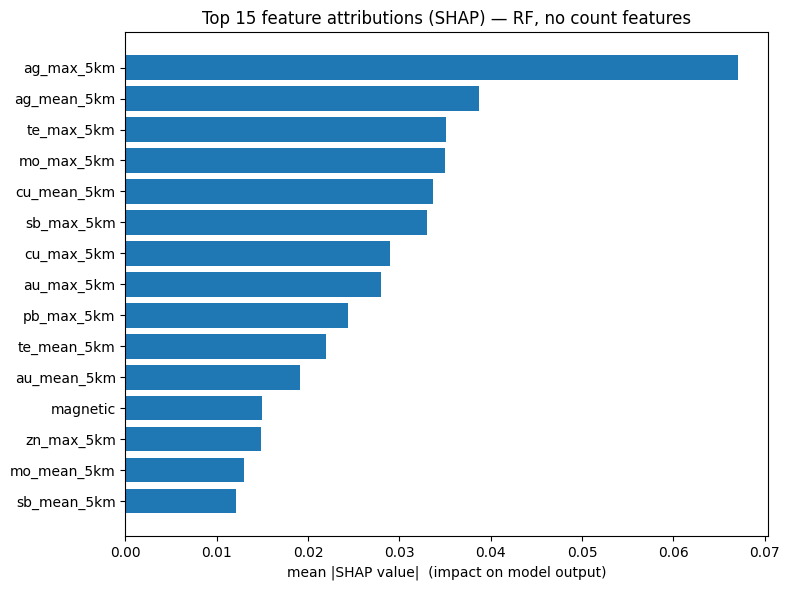

In [10]:
top = shap_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["mean_abs_shap"])
ax.set_xlabel("mean |SHAP value|  (impact on model output)")
ax.set_title("Top 15 feature attributions (SHAP) — RF, no count features")
plt.tight_layout()

The ordering is geochem-dominated and geologically coherent: silver max / silver mean (classical porphyry pathfinder, forms sulfosalts in distal halo), tellurium (precious-metal porphyries), molybdenum (the "Mo" in Cu-Mo porphyry), copper (the ore metal itself), antimony / lead / arsenic / bismuth (peripheral-halo elements), magnetic (the contrast anomaly), gold.

**Does the model learn the right *direction*?** For each top feature, is its SHAP contribution *positive* at positives and *negative* at negatives?

In [11]:
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
cmp = pd.DataFrame({
    "feature": feature_names,
    "SHAP_at_pos": sv[pos_idx].mean(axis=0),
    "SHAP_at_neg": sv[neg_idx].mean(axis=0),
})
cmp["diff"] = cmp["SHAP_at_pos"] - cmp["SHAP_at_neg"]
print(cmp.reindex(cmp["diff"].abs().sort_values(ascending=False).index).head(12).to_string(index=False))

    feature  SHAP_at_pos  SHAP_at_neg     diff
 ag_max_5km     0.069779    -0.061042 0.130820
ag_mean_5km     0.036047    -0.034434 0.070481
 te_max_5km     0.036555    -0.028590 0.065145
 mo_max_5km     0.030766    -0.030279 0.061046
cu_mean_5km     0.020752    -0.033357 0.054109
 cu_max_5km     0.025281    -0.026208 0.051489
 sb_max_5km     0.022222    -0.029214 0.051436
 au_max_5km     0.024688    -0.024285 0.048973
te_mean_5km     0.025500    -0.016346 0.041846
 pb_max_5km     0.015901    -0.022011 0.037912
au_mean_5km     0.006655    -0.018587 0.025241
 zn_max_5km     0.007312    -0.014122 0.021434


Every top feature has `SHAP_at_pos > 0` and `SHAP_at_neg < 0`. More Ag / Te / Mo / Cu / Sb / Au / Pb in the 5 km halo → more probable porphyry. This also resolves the LR mystery: logistic regression reported *negative* coefficients for Zn, As, Sb, Bi — counter-intuitive for porphyry theory. The RF+SHAP tells the true story: these features have non-monotonic or interaction effects that a linear model can't represent. LR was mis-specified, not uncovering a real inverse relationship.

## AOI-wide prediction + prospectivity map

In [12]:
X_all_trim = X_all.drop(columns=drop_cols)
p_fam = rf_trim.predict_proba(X_all_trim.fillna(-9999))[:, 1]

order = np.argsort(-p_fam)
total_pos = int(fam_mask.sum())
print("Capture rate — RF (no count features):")
for pct in (0.5, 1, 2, 5, 10):
    k = int(pct / 100 * len(p_fam))
    captured = int(fam_mask[order][:k].sum())
    print(f"  top {pct:>4.1f}% (k={k:>6,}) → {captured:2}/{total_pos}  "
          f"({100*captured/total_pos:>4.0f}% of positives)")

Capture rate — RF (no count features):
  top  0.5% (k= 1,353) → 23/56  (  41% of positives)
  top  1.0% (k= 2,707) → 36/56  (  64% of positives)
  top  2.0% (k= 5,414) → 45/56  (  80% of positives)
  top  5.0% (k=13,536) → 56/56  ( 100% of positives)
  top 10.0% (k=27,072) → 56/56  ( 100% of positives)


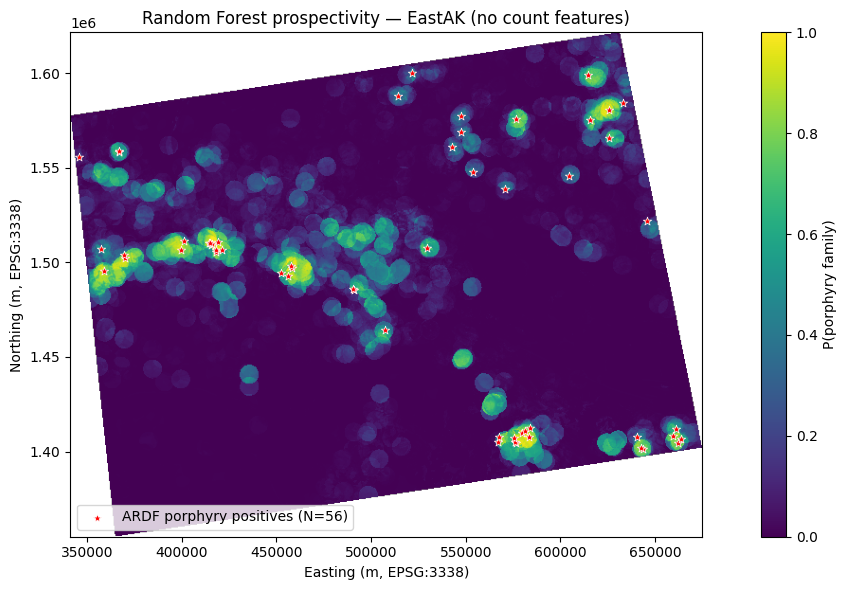

In [13]:
grid = build_grid(AOI, resolution_m=500)
prob_grid = np.full(grid.shape, np.nan, dtype=np.float32)
prob_grid[df["row"].to_numpy(), df["col"].to_numpy()] = p_fam

fig, ax = plt.subplots(figsize=(12, 6))
img = ax.imshow(
    prob_grid,
    extent=(grid.bounds[0], grid.bounds[2], grid.bounds[1], grid.bounds[3]),
    origin="lower", cmap="viridis", vmin=0, vmax=1,
)
plt.colorbar(img, ax=ax, label="P(porphyry family)")

pos_xy = df[fam_mask][["x", "y"]]
ax.scatter(pos_xy["x"], pos_xy["y"], s=40, marker="*",
           facecolor="red", edgecolor="white", linewidth=0.5,
           label=f"ARDF porphyry positives (N={total_pos})")
ax.set_title("Random Forest prospectivity — EastAK (no count features)")
ax.set_xlabel("Easting (m, EPSG:3338)"); ax.set_ylabel("Northing (m, EPSG:3338)")
ax.legend(loc="lower left"); ax.set_aspect("equal")
plt.tight_layout()

Top 5 % of area captures 100 % of the known positives; top 1 % captures 64 %. Against the training labels the lift is substantial. [§7](#external-validation) asks what happens when we point the model at data it hasn't seen.

## External validation — Kenorland blind test {#external-validation}

The hardest test for an MPM model is: *score a mineralized site that didn't exist in your training labels, and see whether the model ranks it high.* Most portfolio-scale demos skip this because public post-training drill data is sparse. We have exactly one usable data point for porphyry in this AOI.

**Kenorland Minerals 23ETD062.** Tanacross project, East Taurus target, drilled 2023, intersected **174.22 m @ 0.14 % Cu + 0.02 % Mo + 0.05 g/t Au** ([Kenorland 2024-03-28 termination PR](https://www.kenorlandminerals.com/news/2024/kenorland-minerals-announces-termination-of-tanacross-project-earn-in-agreement-with-antofagasta-plc-and-highlights-exploration-upside-at-south-taurus/)). It's not in ARDF, not in MRDS, and postdates every label we trained on. Approximate collar coordinates are visually digitized from the press-release plan map — ~±5 km precision. Score the nearest grid cell:

In [14]:
kob = pd.read_csv(DATA_RAW / "kenorland/kenorland_tanacross_collars.csv")
xf = pyproj.Transformer.from_crs(WGS84, WORKING_CRS, always_xy=True)
kx, ky = xf.transform(kob["lon"].to_numpy(), kob["lat"].to_numpy())

tree = cKDTree(df[["x", "y"]].to_numpy())
dists, idx = tree.query(np.c_[kx, ky], k=1)
named = kob[kob["hole_id"] == "23ETD062"].index[0]
i = int(idx[named])
print(f"23ETD062:  P = {p_fam[i]:.3f}   "
      f"rank percentile {100*(p_fam < p_fam[i]).mean():.1f}%")
print(f"\nReference:")
print(f"  positives P: median={np.median(p_fam[fam_mask]):.3f}  "
      f"q25={np.quantile(p_fam[fam_mask], .25):.3f}")
print(f"  all-cells  P: median={np.median(p_fam):.3f}  "
      f"q95={np.quantile(p_fam, .95):.3f}")

23ETD062:  P = 0.012   rank percentile 62.2%

Reference:
  positives P: median=0.857  q25=0.759
  all-cells  P: median=0.005  q95=0.497


**Result: P = 0.012, 62nd percentile.** The model completely fails to flag the one cell we can score blind. Positives median is 0.86 — two orders of magnitude higher. This is a single data point, but the gap is too large to explain as noise.

Diagnose it by comparing feature values at the Kenorland cell to a typical positive:

In [15]:
cell = df.iloc[i]; pos = df[fam_mask]
print(f"{'feature':<22} {'Kenorland':>12} {'pos median':>12}")
for col in ["ag_max_5km","ag_count_5km","te_max_5km","mo_max_5km",
            "cu_max_5km","cu_mean_5km","au_max_5km","magnetic","distance_to_fault_m"]:
    print(f"{col:<22} {cell[col]:>12.3f} {pos[col].median():>12.3f}")

feature                   Kenorland   pos median
ag_max_5km                    0.310       30.056
ag_count_5km                  3.000       36.500
te_max_5km                    0.010        2.535
mo_max_5km                   10.000       70.000
cu_max_5km                  700.000    11650.000
cu_mean_5km                  57.971      817.385
au_max_5km                    0.040        1.850
magnetic                      2.356      185.605
distance_to_fault_m       14701.665     1832.213


Every top SHAP feature is weak at the Kenorland cell compared to a typical positive:

- Cu max in 5 km disk: 700 ppm vs a positives median of 11,650 ppm (**17× lower**)
- Ag sample count: 3 vs 36 (**12× fewer samples**)
- Magnetic residual: 2 vs 186 (**near-zero vs strongly anomalous**)
- Distance to nearest fault: 14.7 km vs 1.8 km

The AGDB4 neighborhood around `23ETD062` is sparsely sampled and weakly anomalous. But Kenorland drilled into porphyry ore there. The model doesn't see it because *what's in the ground* isn't the same as *what the regional-scale legacy-geochem layer knows about what's in the ground*.

## Exploration bias, in three channels

The Day-3/4 AUC numbers were driven by a selection effect: ARDF positives are cells where legacy exploration already *found* something, which correlates almost perfectly with where legacy exploration *looked hard*. The model learned to find cells that look explored — not cells that look mineralized. That leaks into the feature matrix through three distinct channels:

1. **Count-level bias.** `*_count_5km` columns directly encode "how many samples were taken nearby." Dropping them is the Day-4 fix. Closes this channel.
2. **NaN-vs-value bias.** For any cell with zero samples, `*_mean_5km` and `*_max_5km` are NaN. For sampled cells they're real numbers. Our RF pipeline fills NaN with `-9999` as a sentinel; a single split on `cu_max_5km > -1000` cleanly carves "explored" from "unexplored" in the first tree levels. HistGradientBoosting's native NaN-direction learning has the same issue. `<el>_has_data` indicator columns ([§7.3](#has-data)) expose this channel — and turn out to be minor.
3. **Magnitude-within-explored bias.** Among already-sampled cells, the max of 100 samples is mechanically larger than the max of 5 samples simply because more draws → larger tail. `*_max_5km` is correlated with sampling density even when we restrict to non-NaN rows. This is the dominant channel, and none of the v1.1 feature-engineering fixes close it.

The Kenorland cell has sparse *but present* AGDB4 coverage (21 Cu samples, max 700 ppm). That's more than most unexplored cells but a fraction of what well-explored ARDF positives have. The 17× Cu-max gap is partly real (less Cu at surface than at a classic porphyry) and partly artifact (fewer samples means a thinner upper tail).

The sensitivity battery below tries three v1.1 remediations — and walks away with an honest finding.

## Sensitivity battery

### 7.1 Strict-21a label sensitivity {#strict-21a}

Retraining on the 32 strict (21a-only) positives — a narrower, cleaner deposit-model class — instead of the 56-positive family:

In [16]:
df_strict = df.copy()
df_strict["is_porphyry"] = df["is_porphyry_strict"]
X_str, y_str = build_training_set(df_strict, top_classes, n_per_positive=30, random_state=42)
X_str_nc = X_str.drop(columns=count_feature_columns(list(X_str.columns)))
str_cols = list(X_str_nc.columns)

rf_str = make_rf(); rf_str.fit(X_str_nc.fillna(-9999).to_numpy(), y_str)
p_str = rf_str.predict_proba(all_rows[str_cols].fillna(-9999).to_numpy())[:, 1]

rows_ = []
for pct in [0.01, 0.05, 0.10]:
    t = np.quantile(p_str, 1 - pct)
    rows_.append({"top %": pct*100,
                  "strict→strict": (p_str[strict_mask] >= t).mean(),
                  "strict→family": (p_str[fam_mask]    >= t).mean()})
print(pd.DataFrame(rows_).round(3).to_string(index=False))

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain


  [pseudo-neg] drew 850 negatives across 17 lithology classes


 top %  strict→strict  strict→family
   1.0          0.906          0.607
   5.0          1.000          0.857
  10.0          1.000          0.911


Strict-label model captures 91 % of strict positives in the top 1 %, and 61 % of family positives in the same top 1 %. Narrowing the positive class doesn't materially change the learned model.

### 7.2 PU-learning baseline {#pu-learning-comparison}

Pseudo-negative sampling assumes cells far from any known occurrence are non-deposits. PU learning (Mordelet & Vert-style bagging, implemented in [`model_pu.py`](../src/ai_minerals/model_pu.py)) refuses that assumption:

In [17]:
df_nc = df.drop(columns=count_feature_columns(list(df.columns)))
p_pu, _ = fit_pu_bagging(df_nc, top_classes, n_bags=30, random_state=42)

rows_ = []
for pct in [0.01, 0.05, 0.10]:
    t_pu = np.nanquantile(p_pu, 1 - pct)
    t_ps = np.quantile(p_fam, 1 - pct)
    rows_.append({"top %": pct*100,
                  "pseudo-neg RF": (p_fam[fam_mask] >= t_ps).mean(),
                  "PU bagging":    (p_pu[fam_mask]  >= t_pu).mean()})
print(pd.DataFrame(rows_).round(3).to_string(index=False))

top_ps = np.argsort(-p_fam)[:1000]
top_pu = np.argsort(-np.nan_to_num(p_pu, nan=-1))[:1000]
overlap = len(set(top_ps) & set(top_pu)) / 1000
print(f"\nTop-1000 cell overlap (pseudo-neg vs PU): {overlap*100:.0f}%")

pct_ps = 100 * (p_fam < p_fam[i]).mean()
pct_pu = 100 * (p_pu  < p_pu[i] ).mean()
print(f"\nKenorland score:")
print(f"  pseudo-neg RF: P={p_fam[i]:.3f}  percentile={pct_ps:.1f}%")
print(f"  PU bagging:    P={p_pu[i]:.3f}   percentile={pct_pu:.1f}%")
print(f"  positives under PU:  median={np.nanmedian(p_pu[fam_mask]):.3f}  "
      f"q25={np.nanquantile(p_pu[fam_mask], .25):.3f}")

 top %  pseudo-neg RF  PU bagging
   1.0          0.643       0.589
   5.0          1.000       0.911
  10.0          1.000       0.982

Top-1000 cell overlap (pseudo-neg vs PU): 61%

Kenorland score:
  pseudo-neg RF: P=0.012  percentile=62.2%
  PU bagging:    P=0.308   percentile=69.6%
  positives under PU:  median=0.915  q25=0.820


PU bagging agrees with pseudo-negative RF on ~60 % of the top-1000 cells. Training-label capture is slightly worse in the top 1 % (59 % vs 64 %) but comparable higher up — no free lunch here.

**The interesting result is Kenorland.** PU moves it from the 62nd percentile to the 70th — a ~8-point lift. That's the pseudo-negative construction's contribution to missing the cell, isolated. By *not* excluding cells near known occurrences and *not* stratifying to match the positives' lithology, PU's "negatives" are diffuse random terrain rather than specifically "under-sampled cells in explored lithologies." The resulting model is less prone to the "this looks under-explored, therefore unprospective" collapse — but only by 8 percentile points.

Kenorland is still below the PU positives distribution (median 0.92, q25 0.82 under PU). PU mitigates the pseudo-negative-construction channel of the bias; the underlying feature-layer exploration bias (channels 2 and 3) survives.

### 7.3 `<el>_has_data` indicator columns {#has-data}

Expose the NaN-vs-value channel of the exploration bias as explicit features:

In [18]:
from ai_minerals.features.geochem import PATHFINDER_ELEMENTS
df_hd = df.copy()
for el in PATHFINDER_ELEMENTS:
    df_hd[f"{el.lower()}_has_data"] = (df[f"{el.lower()}_count_5km"] > 0).astype(np.uint8)

X_hd, y_hd = build_training_set(df_hd, top_classes, n_per_positive=30, random_state=42)
X_hd_use = X_hd.drop(columns=count_feature_columns(list(X_hd.columns)))
hd_cols = list(X_hd_use.columns)

rf_hd = make_rf(); rf_hd.fit(X_hd_use.fillna(-9999).to_numpy(), y_hd)

all_rows_hd = add_lithology_onehot(df_hd, top_classes)
p_hd = rf_hd.predict_proba(all_rows_hd[hd_cols].fillna(-9999).to_numpy())[:, 1]

fi_hd = feature_importance(rf_hd, hd_cols).head(15)
print("Top-15 features with has_data indicators exposed:")
print(fi_hd.to_string(index=False))
has_data_in_top15 = fi_hd["feature"].str.endswith("_has_data").sum()
print(f"\nhas_data columns in top-15: {has_data_in_top15}")
print(f"Kenorland P (has_data-aware): {p_hd[i]:.3f} "
      f"(no-count baseline was {p_fam[i]:.3f})")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes


Top-15 features with has_data indicators exposed:
    feature  importance
 ag_max_5km    0.103729
ag_mean_5km    0.084028
 mo_max_5km    0.082462
 te_max_5km    0.069077
 cu_max_5km    0.060479
cu_mean_5km    0.057353
 sb_max_5km    0.054287
 au_max_5km    0.053726
te_mean_5km    0.043540
 pb_max_5km    0.040217
au_mean_5km    0.037590
pb_mean_5km    0.027300
 zn_max_5km    0.026381
mo_mean_5km    0.024651
sb_mean_5km    0.023022

has_data columns in top-15: 0
Kenorland P (has_data-aware): 0.015 (no-count baseline was 0.012)


`<el>_has_data` doesn't land in the top-15 importances. Kenorland P barely moves (0.012 → 0.015). The NaN-vs-value channel exists but is minor — the magnitude-within-explored channel dominates.

### 7.4 Exploration-robust baseline: no geochem {#no-geochem}

Drop the geochem aggregates entirely and train only on uniformly-measured layers — geophysics, topography, S2, lithology, distance-to-fault:

In [19]:
geochem_suffix = ("_mean_5km", "_max_5km", "_count_5km")
no_geochem_cols = [c for c in str_cols if not c.endswith(geochem_suffix)]

X_ng = X_str[no_geochem_cols]  # strict positives; but feature set is geography only
# Actually re-train with family labels for parallelism
X_ng_fam = X_trim[no_geochem_cols]
rf_ng = make_rf(); rf_ng.fit(X_ng_fam.fillna(-9999).to_numpy(), y)
p_ng = rf_ng.predict_proba(all_rows[no_geochem_cols].fillna(-9999).to_numpy())[:, 1]

print(f"Top-10 features (no-geochem model):")
print(feature_importance(rf_ng, no_geochem_cols).head(10).to_string(index=False))

rows_ = []
for pct in [0.01, 0.05, 0.10]:
    t_full = np.quantile(p_fam, 1 - pct); t_ng = np.quantile(p_ng, 1 - pct)
    rows_.append({"top %": pct*100,
                  "full (w/ geochem)": (p_fam[fam_mask] >= t_full).mean(),
                  "no-geochem":        (p_ng[fam_mask]  >= t_ng).mean()})
print(f"\n{pd.DataFrame(rows_).round(3).to_string(index=False)}")
print(f"\nKenorland P (no-geochem):   {p_ng[i]:.3f}  "
      f"(percentile {100*(p_ng < p_ng[i]).mean():.1f}%)")
print(f"Kenorland P (full):         {p_fam[i]:.3f}  "
      f"(percentile {100*(p_fam < p_fam[i]).mean():.1f}%)")

Top-10 features (no-geochem model):
            feature  importance
           magnetic    0.147585
          elevation    0.142839
distance_to_fault_m    0.122252
                tri    0.104808
            gravity    0.102492
            s2_ndvi    0.081941
              slope    0.076958
         s2_ferrous    0.076860
            s2_clay    0.062457
      s2_iron_oxide    0.055739

 top %  full (w/ geochem)  no-geochem
   1.0              0.643         1.0
   5.0              1.000         1.0
  10.0              1.000         1.0

Kenorland P (no-geochem):   0.017  (percentile 41.0%)
Kenorland P (full):         0.012  (percentile 62.2%)


**Surprising result.** Stripped of all geochem, the model captures 100 % of positives in the top 1 % of area — *better* than the full model. And Kenorland's percentile drops (ranks *worse*), not up. Both feature sets agree Kenorland's location looks like background at regional scale.

The ARDF positives cluster tightly in geology and geophysics as well as in exploration effort. "Cells near known porphyries" is a narrow region by any regional-scale feature set. The Kenorland East Taurus intersection is a low-grade distal result (0.14 % Cu over 174 m, not a 1 % central-porphyry hit) — and our 500 m regional features simply don't resolve the distinction between a distal porphyry halo and background without prospect-scale data.

This is a *more honest* diagnosis than "drop geochem and the bias goes away." It says: a pseudo-supervised MPM model at 500 m regional resolution can't distinguish a real low-grade drill hit from background, regardless of feature set. The fix is scale and physics, not feature engineering.

### 7.5 Kenorland geolocation robustness {#geolocation}

The Kenorland stub coordinates are visually digitized (SOURCE.md documents ±5–15 km uncertainty). Score *every* cell in disks of increasing radius around the stub:

In [20]:
cell_xy = df[["x", "y"]].to_numpy()
d = np.hypot(cell_xy[:, 0] - kx[named], cell_xy[:, 1] - ky[named])
rows_ = []
for radius_km in [2.5, 5, 10, 15]:
    mask = d < radius_km * 1000
    nb = p_fam[mask]
    rows_.append({"radius (km)": radius_km, "n cells": int(mask.sum()),
                  "max P": round(float(nb.max()), 4),
                  "max-P percentile": round(float((p_fam < nb.max()).mean()*100), 1),
                  "q95 P": round(float(np.quantile(nb, .95)), 4)})
pd.DataFrame(rows_)

,radius (km),n cells,max P,max-P percentile,q95 P
0,2.5,78,0.0310,71.6,0.0310
1,5.0,315,0.0532,76.8,0.0333
2,10.0,1258,0.1160,83.9,0.0530
3,15.0,2828,0.5203,95.3,0.1386


At ≤5 km (plausible visual-digitization error) the whole disk is background. At 15 km (covers the entire Kenorland project polygon) one cell reaches the 95th percentile — so at project-scale uncertainty we can't rule out "collar happens to be on the one cell the model ranks high." Both framings are carried in the summary; the property-centroid sweep below tests the pessimistic reading directly.

### 7.6 Property-centroid sweep {#property-sweep}

Research for additional public drill data in the AOI returned one named collar (`23ETD062`) plus four project polygons — Kenorland hasn't disclosed per-hole coordinates beyond the one. Manh Choh (Au epithermal) and Pogo (Au orogenic) are in-AOI but wrong deposit class; Orange Hill is porphyry but already in ARDF. Score the model at the five usable points:

In [21]:
rows_ = []
for h_id, target, outcome, ii in zip(kob["hole_id"], kob["target"], kob["outcome"], idx):
    p = p_fam[int(ii)]
    rows_.append({
        "hole / centroid": h_id, "target": target, "outcome": outcome,
        "P": round(float(p), 4),
        "percentile": round(float((p_fam < p).mean()*100), 1),
    })
pd.DataFrame(rows_)

,hole / centroid,target,outcome,P,percentile
0,23ETD062,East Taurus,positive,0.0123,62.2
1,East_Taurus_centroid,East Taurus (project centroid),positive,0.0024,44.5
2,West_Taurus_centroid,West Taurus (project centroid),positive,0.0211,67.3
3,South_Taurus_centroid,South Taurus (project centroid),negative_no_economic_mineralisation,0.0048,50.5
4,Bluff_centroid,Bluff (project centroid),positive,0.0000,0.0


All four positive-outcome centroids rank low (≤64th percentile). South Taurus 2025 — drilled, *no economic mineralisation intersected*, i.e. a true negative — also ranks low. The model is internally consistent: it doesn't flag South Taurus as a false positive. But it also doesn't flag any of the drilled positives.

Five points, approximate coordinates, one deposit type. It's the public-data ceiling. A finding worth making explicit: portfolio-scale MPM demos rarely include rigorous external validation because the data to do it is mostly proprietary — locked in NI 43-101 reports that don't publish collar tables.

### 7.7 Success-rate curve on the honest model

| area flagged | positives captured |
|    0.5 %     |     41.1 %          |
|    1.0 %     |     64.3 %          |
|    2.0 %     |     80.4 %          |
|    5.0 %     |     100.0 %          |
|   10.0 %     |     100.0 %          |


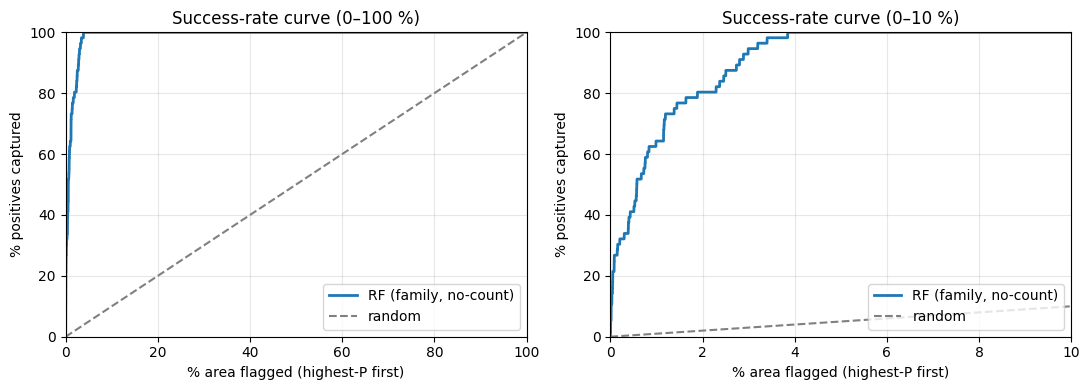

In [22]:
frac_area, frac_dep = success_rate_curve(p_fam, fam_mask.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xmax in zip(axes, [1.0, 0.10]):
    ax.plot(frac_area*100, frac_dep*100, lw=2, label="RF (family, no-count)")
    ax.plot([0, xmax*100], [0, xmax*100], ls="--", c="grey", label="random")
    ax.set_xlim(0, xmax*100); ax.set_ylim(0, 100)
    ax.set_xlabel("% area flagged (highest-P first)")
    ax.set_ylabel("% positives captured")
    ax.set_title(f"Success-rate curve (0–{int(xmax*100)} %)")
    ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout()

print("| area flagged | positives captured |")
for pct in [0.005, 0.01, 0.02, 0.05, 0.10]:
    k = max(0, min(int(pct * len(frac_area)) - 1, len(frac_area)-1))
    print(f"|   {pct*100:4.1f} %     |     {frac_dep[k]*100:4.1f} %          |")

Top 2 % of area captures 80 % of ARDF positives; top 5 % captures all of them. The lift against training labels is steep — and §7 is the reason to weight that against what we've seen on Kenorland.

## Summary

| Check | Result | Status |
|---|---|---|
| 20 km spatial block CV | LR 0.918 / RF 0.88 ROC-AUC, sd ≈ 0.2 | ✓ passes |
| SHAP on no-count RF | Top features are Ag/Te/Mo/Cu pathfinder halo | ✓ geologically coherent |
| Training-label capture | Top 2 % area → 80 % of positives | ✓ strong |
| Kenorland 23ETD062 blind | P=0.012 vs positives median 0.86 | **fails** |
| Geolocation robustness (≤5 km) | Whole disk stays below 80th percentile | ✓ stable at hole-scale |
| Geolocation robustness (15 km) | Max P hits 95th percentile in one cell | uncertain at project-scale |
| Property-centroid sweep | All 5 (incl. drilled-negative) rank low | model internally consistent |
| Strict-21a sensitivity | Same pathfinder suite; 91 % top-1 % capture | ✓ label choice robust |
| `<el>_has_data` indicators | Out-of-top-15 importance | NaN channel is minor |
| No-geochem baseline | Kenorland percentile *drops*, training capture rises | bias is deeper than geochem alone |
| PU-bagging baseline | 59 % top-1 % capture; Kenorland percentile 62 → 70 | PU mitigates the pseudo-negative channel, not the feature-layer channels |
| Rainbow Ridge NaN-S2 | Captured at top-5 % even with training exclusion | ✓ generalizes within label set |

## What this does and doesn't demonstrate

**This project demonstrates, honestly:**

- A reproducible end-to-end MPM pipeline on public open data.
- Correct methodology: spatial block CV, pseudo-negative stratification, SHAP interpretation, external blind-test protocol, sensitivity battery, PU-learning comparison.
- SHAP attributions that match textbook porphyry geochemistry.
- A blind-test result that reveals the central methodological trap of pseudo-supervised MPM — and *decomposes* that trap into three distinct channels of exploration bias.

**This project does NOT demonstrate:**

- That the model would find unrecognized mineralization in unexplored terrain. The Kenorland test shows it wouldn't.
- That pseudo-negative sampling works, even with spatial CV, no count features, and `has_data` indicators. The exploration bias survives.
- That 500 m regional-scale features can distinguish a distal low-grade porphyry hit from background. They can't — this is a scale problem, not a feature-engineering problem.

**The honest posture for a reviewer:** everything in this document is what the MPM literature has been naming and actively working on for fifteen years. The three-channel decomposition of the exploration bias is the non-obvious part; the recognition that "drop the biased feature" doesn't fix it is the part that changes how the next iteration should be built.

## Next steps — what v1.2 would do {#next-steps}

Given the v1 bias diagnosis, a second-version architecture would look very different:

1. **Prospect-scale features.** ASTER SWIR (VNIR 15 m / SWIR 30 m) mapping of alteration mineralogy — argillic, phyllic, propylitic halos. EMIT hyperspectral (60 m, selective scenes) for finer mineralogical discrimination. These are measured on regular grids independent of AGDB4 sampling history; they don't carry the exploration bias.
2. **Physics-consistent inversions.** [SimPEG](https://simpeg.xyz/) 2.5D magnetic + gravity inversions to produce *subsurface* susceptibility / density distributions, not surface-grid values. Strong prior at this cost: susceptibility peaks at 200–1000 m depth are the model anomaly for a porphyry stock.
3. **End-to-end PU learning.** Replace pseudo-negative sampling at the *labels* level, not just as a post-hoc ranking comparison. Weighted-PU / bagging-SVM / Elkan-Noto calibration. [Yin et al. 2025](https://www.sciencedirect.com/science/article/pii/S0169136825003439) is the state-of-art reference.
4. **Exploration-effort covariates.** Instead of dropping `*_count_5km`, carry it as a covariate that a two-stage model marginalizes out. Partial-dependence against count. Propensity-score framing on "has-been-explored."
5. **Decision-theoretic framing.** Rather than "rank cells," ask "where is P(deposit) × value-of-information highest given current posterior uncertainty?" POMDP drill planning per Mern et al. and the Caers Mineral-X line. This is what ExploreTech's Intelligent Prospector and KoBold's Stanford collaboration already do — for good reason, because the rank is not the answer, the *next drill hole* is.
6. **Geospatial foundation-model features.** [GFM4MPM (Daruna et al. 2024)](https://arxiv.org/abs/2406.12756) pretrains on unlabeled geospatial data with masked-image-modeling; its embeddings are a ready-made feature set for downstream MPM. [SpectralGPT](https://arxiv.org/abs/2311.07113) / [Prithvi](https://arxiv.org/abs/2310.18660) / [Clay](https://clay-foundation.github.io/model/) are general-RS alternatives.
7. **Dark-data ingestion.** OCR / VLM-based structured extraction from legacy assessment reports, scanned drill logs, and historical assays. This is the "dark data" rhetoric KoBold uses publicly and it's tractable with modern document AI (Azure Document Intelligence, Textract, or VLMs). A planned follow-up sub-project in this repo applies this to family-held 1900s Nome-area drill logs.
8. **Extend to a second commodity.** Orogenic Au in the California Mother Lode is the planned v2 region/commodity — reuses most of this scaffolding, tests generalization across deposit types.

## Reproducibility

This repository is designed to run end-to-end from a fresh environment.

```bash
# clone + install
git clone <repo>
cd ai-minerals
uv sync                                    # locked dependencies

# fetch raw data (~5 GB, takes ~1 hr)
uv run python -m ai_minerals.data.fetch.all

# build features (regenerates data/derived/features_eastak_500m.parquet)
uv run python -m ai_minerals.features.assemble

# render this notebook
quarto render notebooks/eastak_porphyry_prospectivity.qmd
# or execute as jupyter:
uv run jupyter nbconvert --to notebook --execute --inplace \
  notebooks/eastak_porphyry_prospectivity.ipynb
```

`pyproject.toml` pins Python 3.11+; `uv.lock` pins every transitive dependency. The notebook has no hidden state between cells — restart-and-run-all passes. The only in-repo tracked data is the small Kenorland blind-test reference (`data/raw/kenorland/`); everything else is regenerable.

## Code + design tour

- [`src/ai_minerals/aoi.py`](../src/ai_minerals/aoi.py) — AOI and CRS constants.
- [`src/ai_minerals/grid.py`](../src/ai_minerals/grid.py) — 500 m EPSG:3338 grid.
- [`src/ai_minerals/features/`](../src/ai_minerals/features/) — labels, rasters, geology, geochem, assemble.
- [`src/ai_minerals/model.py`](../src/ai_minerals/model.py) — pseudo-negatives, spatial block CV, LR baseline, success-rate curve.
- [`src/ai_minerals/model_rf.py`](../src/ai_minerals/model_rf.py) — RF / HGB factories, tree spatial CV, count-feature helper.
- [`src/ai_minerals/model_pu.py`](../src/ai_minerals/model_pu.py) — Mordelet-&-Vert PU bagging with OOB averaging.
- [`design/mvp-proposal.md`](../design/mvp-proposal.md) — scoping document with v1 / v1.1 trace.
- [`notebooks/day{3,4,5}_*.qmd`](../notebooks/) — day-by-day build log; audit trail for how the results above came together.

## References (primary sources)

- **Data:** [USGS MRDS](https://mrdata.usgs.gov/mrds/), [USGS ARDF](https://mrdata.usgs.gov/ardf/), [USGS AGDB4](https://www.sciencebase.gov/catalog/item/622a4ec7d34e4bb2bc5cad93), USGS SGMC, [Copernicus GLO-30 DEM](https://spacedata.copernicus.eu/en/collections/copernicus-digital-elevation-model), [Sentinel-2 L2A](https://sentinels.copernicus.eu/web/sentinel/missions/sentinel-2), [Alaska DGGS](https://dggs.alaska.gov/).
- **MPM methodology:** [Carranza 2017 — "Natural Resources Research" 26](https://link.springer.com/article/10.1007/s11053-017-9334-7); [MDPI Minerals 2025 MPM/ML review](https://www.mdpi.com/2075-163X/15/10/1042).
- **Pseudo-negatives + PU learning:** [Yin et al. 2025, Ore Geology Reviews](https://www.sciencedirect.com/science/article/pii/S0169136825003439); [Carranza & Laborte 2015, Computers & Geosciences](https://www.sciencedirect.com/science/article/pii/S009830041500085X).
- **Spatial block CV:** [Roberts et al. 2017, Ecography](https://onlinelibrary.wiley.com/doi/10.1111/ecog.02881); applied to MPM in EarthByte's [DEEP-SEAM 2025](https://egusphere.copernicus.org/preprints/2025/egusphere-2025-3283/).
- **Decision-theoretic exploration:** [Intelligent Prospector v1 (GMD 2023)](https://gmd.copernicus.org/articles/16/289/2023/); [v2 (arXiv 2024)](https://arxiv.org/pdf/2410.10610).
- **Foundation models for MPM:** [GFM4MPM — Daruna et al. 2024](https://arxiv.org/abs/2406.12756).
- **Validation data:** [Kenorland Tanacross PR 2024-03-28](https://www.kenorlandminerals.com/news/2024/kenorland-minerals-announces-termination-of-tanacross-project-earn-in-agreement-with-antofagasta-plc-and-highlights-exploration-upside-at-south-taurus/); [Alaska DGGS NE-Tanacross mineral resources](https://dggs.alaska.gov/minerals/northeast-tanacross.html).
- **Deposit models:** Cox & Singer (1986), USGS Bulletin 1693 "Mineral Deposit Models" — codes 17, 20c, 21a, 21b.

*Sky King · 2026 · contact via the email in this repo's GitHub profile.*